In [478]:
#날짜별로 변하는 것은 시계열 데이터
#아리마(ARIMA 모델)
# 다운 패키지: pip install finance data ffinance-datareader (그 외 Yahoo finance 등 여러 패키지가 있음)

#불러오기
import FinanceDataReader as fdr

In [479]:
df_stock=fdr.StockListing('KRX') #미: NYSE
df_stock.head()

,Code,ISU_CD,Name,Market,Dept,Close,ChangeCode,Changes,ChagesRatio,Open,High,Low,Volume,Amount,Marcap,Stocks,MarketId
0,005930,KR7005930003,삼성전자,KOSPI,,86000,1,2100,2.50,84900,86200,84700,22039361,1886160393690,509088861292000,5919637922,STK
1,000660,KR7000660001,SK하이닉스,KOSPI,,360000,1,12500,3.60,351000,362000,351000,2802437,1001954505000,262080851400000,728002365,STK
2,373220,KR7373220003,LG에너지솔루션,KOSPI,,347500,3,0,0.00,349000,351000,341000,141477,48966620250,81315000000000,234000000,STK
3,207940,KR7207940008,삼성바이오로직스,KOSPI,,1005000,1,8000,0.80,999000,1012000,999000,64286,64638117000,71529870000000,71174000,STK
4,012450,KR7012450003,한화에어로스페이스,KOSPI,,1099000,2,-8000,-0.72,1100000,1113000,1081000,158652,173734761500,56668177699000,51563401,STK


In [480]:
#삼성이 들어가는 기업을 출력하기(.str.contains(""), filt 함수 지정)
filt=df_stock['Name'].str.contains('삼성')
df_stock[filt]

,Code,ISU_CD,Name,Market,Dept,Close,ChangeCode,Changes,ChagesRatio,Open,High,Low,Volume,Amount,Marcap,Stocks,MarketId
0,005930,KR7005930003,삼성전자,KOSPI,,86000,1,2100,2.50,84900,86200,84700,22039361,1886160393690,509088861292000,5919637922,STK
3,207940,KR7207940008,삼성바이오로직스,KOSPI,,1005000,1,8000,0.80,999000,1012000,999000,64286,64638117000,71529870000000,71174000,STK
5,005935,KR7005931001,삼성전자우,KOSPI,,68000,1,1600,2.41,67000,68000,66800,2527098,170906368350,55486277152000,815974664,STK
15,028260,KR7028260008,삼성물산,KOSPI,,188500,1,3900,2.11,185600,189100,185500,211186,39700454750,32040578544000,169976544,STK
16,032830,KR7032830002,삼성생명,KOSPI,,155100,2,-1500,-0.96,156700,158500,154000,178898,27813186000,31020000000000,200000000,STK
27,000810,KR7000810002,삼성화재,KOSPI,,451500,3,0,0.00,457000,457500,449500,41120,18582901000,20774036482500,46011155,STK
32,010140,KR7010140002,삼성중공업,KOSPI,,21850,2,-50,-0.23,22000,22050,21525,3155674,68771057575,19228000000000,880000000,STK
35,006400,KR7006400006,삼성SDI,KOSPI,,204000,2,-1000,-0.49,206000,207500,203000,216933,44375968500,16439448120000,80585530,STK
39,009150,KR7009150004,삼성전기,KOSPI,,193300,2,-200,-0.10,195800,196300,190800,404107,78215170850,14438291436800,74693696,STK
42,018260,KR7018260000,삼성에스디에스,KOSPI,,166600,1,2400,1.46,164800,168000,163700,156640,25948130100,12891141480000,77377800,STK


In [481]:
#특정코드를 가지고 1월부터 12월까지의 데이터를 가지고 오기(DataReader)
code="005930" #예시 삼성전자 코드
df=fdr.DataReader(code,"2024-01-01","2024-12-31")
df.shape #184일 확인 가능

(244, 6)

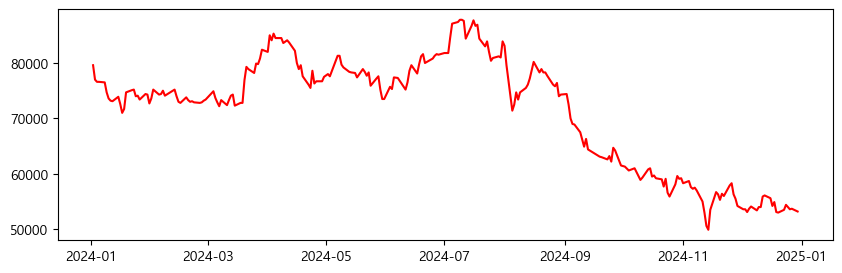

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2024-01-02,78200,79800,78200,79600,17142847,0.014013
2024-01-03,78500,78800,77000,77000,21753644,-0.032663
2024-01-04,76100,77300,76100,76600,15324439,-0.005195
2024-01-05,76700,77100,76400,76600,11304316,0.000000
2024-01-08,77000,77500,76400,76500,11088724,-0.001305


In [482]:
#특정코드 데이터(DataReader)를 시각화하기
import FinanceDataReader as fdr
import matplotlib.pyplot as plt

plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)
df.tail(5)
df.index #timestamp 날짜 데이터 확인
#마감장을 기준으로 주가 비교
plt.figure(figsize=(10,3))
plt.plot(df.index,df['Close'],c='r')
plt.show()
df.head()

In [483]:
df['년']=df.index.year
df['월']=df.index.month
df['일']=df.index.day



In [484]:
df=df[df['년']==2024]
df.tail()

group=df.groupby('월')[['Close','Volume']].mean()
group['Vol']=round(group['Volume']/1000,2)
group.head()

,Close,Volume,Vol
월,,,
1,74454.545455,1.807449e+07,18074.49
2,73684.210526,1.573450e+07,15734.50
3,75760.000000,2.241809e+07,22418.09
4,80595.238095,2.306391e+07,23063.91
5,77780.000000,2.105444e+07,21054.44


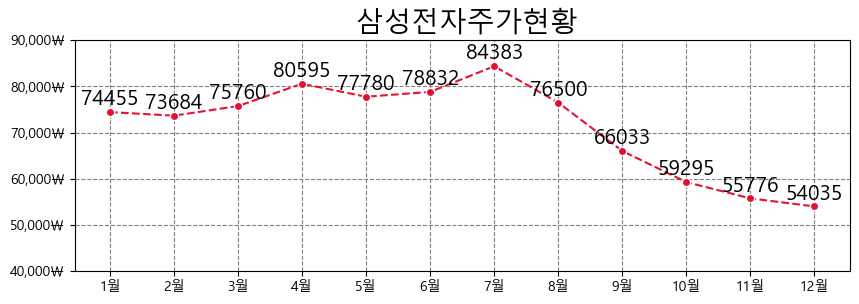

In [485]:
import numpy as np

df=group.copy()
plt.figure(figsize=(10,3))
plt.plot(df.index,df['Close'],marker='o',c="#E6092BF6",ls='--',mec='w')
plt.title(' 삼성전자주가현황',size=20,ha="center")
xticks=[x for x in df.index]
plt.xticks(xticks,[f'{x}월' for x in xticks])
plt.ylim(min(df['Close'])-5000,max(df['Close'])+5000)
ymin=int((df['Close'].min()-5000)/10000)*10000
ymax=int(df['Close'].max()+10000)
yticks=[y for y in range(ymin, ymax, 10000)]
plt.yticks(yticks,[f'{y:,}￦' for y in yticks])
plt.grid(True,c='gray',ls='--')
for idx,close in enumerate(df['Close']):
    plt.text(idx+1,close+1500,f"{close:.0f}",ha="center", size=15)

plt.show()


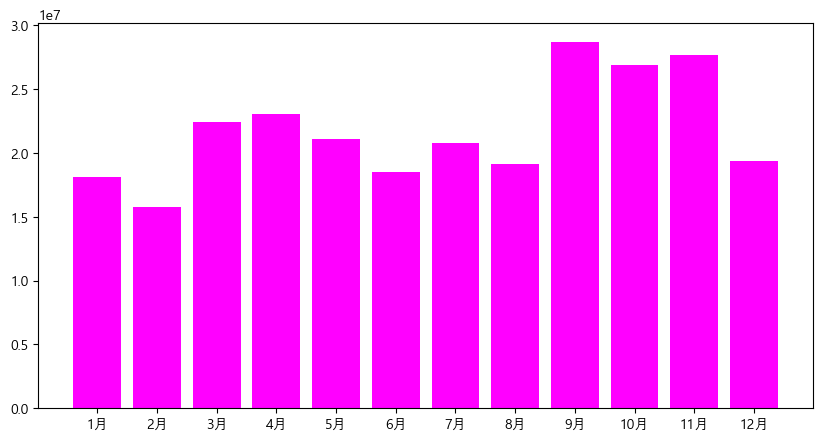

In [486]:
plt.figure(figsize=(10,5))
plt.bar(df.index, df['Volume'],color='magenta')
xticks=[x for x in df.index]
plt.xticks(xticks,[f'{x}月' for x in xticks])
plt.show()


In [487]:
#ARIMA를 통한 시계열 분석
code='005930'
ss=fdr.DataReader(code,'2020-1-1','2021-8-31')
ss.tail()

# 데이터의 70%를 train데이터로, 나머지를 test 데이터로 활용
n_train=int(len(ss)*0.7)
len(ss),n_train

#cf) Close 종가지수
y_train=ss['Close'][:n_train] #289개의 Close의 train데이터를 가지고 옴
# y_train
y_test=ss['Close'][n_train:]

len(y_train), len(y_test)

(289, 125)

Text(0, 0.5, 'Price')

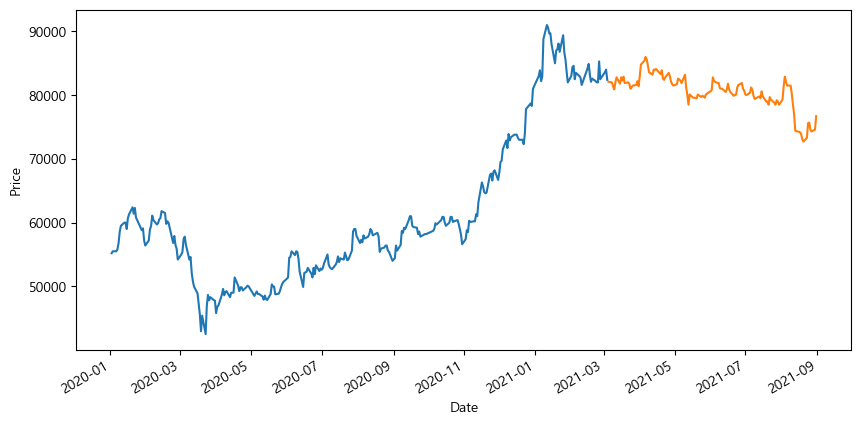

In [488]:
y_train[:5], y_test[:5]
plt.figure(figsize=(10,5))
#간단하게 표 만들기(x,y1개여서 지정 필요X 경우)
y_train.plot()
y_test.plot()
plt.ylabel('Price')



In [489]:
#차분개선을 위한 라이브러리
import warnings
warnings.filterwarnings('ignore') #warning 무시하기
# pip install pmdarima==2.0.4 (==는 버전 지정을 해줌, numpy와 충돌하는 버전이 있어서 버전을 지정)
from pmdarima.arima import ndiffs
ndif=ndiffs(y_train,alpha=0.05 ,test='kpss',max_d=6)
ndif

1

In [490]:
import pmdarima as pm
model=pm.auto_arima(
    y_train, d=1, start_P=0,max_p=3, start_q=0, max_q=3, seasonal=False, trace=True
)
#학습시키기(ARIMA 모델 생성하기)
model.fit(y_train)

#예측하기
y_pred=model.predict(n_periods=len(y_test))

Performing stepwise search to minimize aic
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=4938.772, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=4934.821, Time=0.00 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=4936.780, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=4936.799, Time=0.01 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=4934.428, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=4938.798, Time=0.04 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.124 seconds


In [491]:
def one_stop():
    pred, conf_int= model.predict(n_periods=1,return_conf_int=True)
    print('예측',pred.tolist()[0])
    print('예측 하한, 상한:', conf_int[0])
    return pred.tolist()[0], conf_int[0]

In [492]:
from pmdarima.arima import ndiffs
ndif = ndiffs(y_train, alpha=0.05, test='kpss', max_d=6)
ndif

1

In [493]:
#뽑은 데이터를 담는 리스트
y_pred=[]
y_lower=[]
y_upper=[]

#test 데이터를 하나씩 꺼내서 배열에 append 하여 모델을 업데이트 함(ARIMA 알고리즘)
for test in y_test:
    pred, conf=one_stop()
    y_pred.append(pred)
    y_lower.append(conf[0])
    y_upper.append(conf[1])
    model.update(test)

len(y_pred), len(y_lower), len(y_upper)


예측 82400.0
예측 하한, 상한: [79921.28905069 84878.71094931]
예측 82100.0
예측 하한, 상한: [79621.28905069 84578.71094931]
예측 82000.0
예측 하한, 상한: [79521.28905069 84478.71094931]
예측 81400.0
예측 하한, 상한: [78921.28905069 83878.71094931]
예측 80900.0
예측 하한, 상한: [78421.28905069 83378.71094931]
예측 82000.0
예측 하한, 상한: [79521.28905069 84478.71094931]
예측 82800.0
예측 하한, 상한: [80321.28905069 85278.71094931]
예측 81800.0
예측 하한, 상한: [79323.24901468 84276.75098532]
예측 82800.0
예측 하한, 상한: [80323.24901468 85276.75098532]
예측 82300.0
예측 하한, 상한: [79842.53932145 84757.46067855]
예측 82900.0
예측 하한, 상한: [80442.53932145 85357.46067855]
예측 81900.0
예측 하한, 상한: [79442.53932145 84357.46067855]
예측 82000.0
예측 하한, 상한: [79542.53932145 84457.46067855]
예측 81800.0
예측 하한, 상한: [79342.53932145 84257.46067855]
예측 81000.0
예측 하한, 상한: [78542.53932145 83457.46067855]
예측 81200.0
예측 하한, 상한: [78761.55753523 83638.44246477]
예측 81500.0
예측 하한, 상한: [79061.55753523 83938.44246477]
예측 81600.0
예측 하한, 상한: [79161.55753523 84038.44246477]
예측 82200.0
예측 하한, 상한: [79761

(125, 125, 125)

In [494]:
#예측값, 하한가, 상한가
y_pred[0], y_lower[0], y_upper[0]

(82400.0, 79921.28905069064, 84878.71094930936)

In [495]:
#데이터값을 시리즈값으로 변경
import pandas as pd
pred=pd.Series(y_pred, index=y_test.index)
lower=pd.Series(y_lower,index=y_test.index)
upper=pd.Series(y_upper,index=y_test.index)

pred, lower, upper

(Date
 2021-03-05    82400.0
 2021-03-08    82100.0
 2021-03-09    82000.0
 2021-03-10    81400.0
 2021-03-11    80900.0
                ...   
 2021-08-25    75600.0
 2021-08-26    75700.0
 2021-08-27    74600.0
 2021-08-30    74300.0
 2021-08-31    74600.0
 Length: 125, dtype: float64,
 Date
 2021-03-05    79921.289051
 2021-03-08    79621.289051
 2021-03-09    79521.289051
 2021-03-10    78921.289051
 2021-03-11    78421.289051
                   ...     
 2021-08-25    73340.218891
 2021-08-26    73440.218891
 2021-08-27    72340.218891
 2021-08-30    72040.218891
 2021-08-31    72340.218891
 Length: 125, dtype: float64,
 Date
 2021-03-05    84878.710949
 2021-03-08    84578.710949
 2021-03-09    84478.710949
 2021-03-10    83878.710949
 2021-03-11    83378.710949
                   ...     
 2021-08-25    77859.781109
 2021-08-26    77959.781109
 2021-08-27    76859.781109
 2021-08-30    76559.781109
 2021-08-31    76859.781109
 Length: 125, dtype: float64)

In [496]:
data={'예측':y_pred,'하한':y_lower,'상한':y_upper}
df=pd.DataFrame(data, index=y_test.index)
df['실제']=y_test #어제의 실제값이 오늘의 예측값으로 인식됨
df

,예측,하한,상한,실제
Date,,,,
2021-03-05,82400.0,79921.289051,84878.710949,82100
2021-03-08,82100.0,79621.289051,84578.710949,82000
2021-03-09,82000.0,79521.289051,84478.710949,81400
2021-03-10,81400.0,78921.289051,83878.710949,80900
2021-03-11,80900.0,78421.289051,83378.710949,82000
...,...,...,...,...
2021-08-25,75600.0,73340.218891,77859.781109,75700
2021-08-26,75700.0,73440.218891,77959.781109,74600
2021-08-27,74600.0,72340.218891,76859.781109,74300


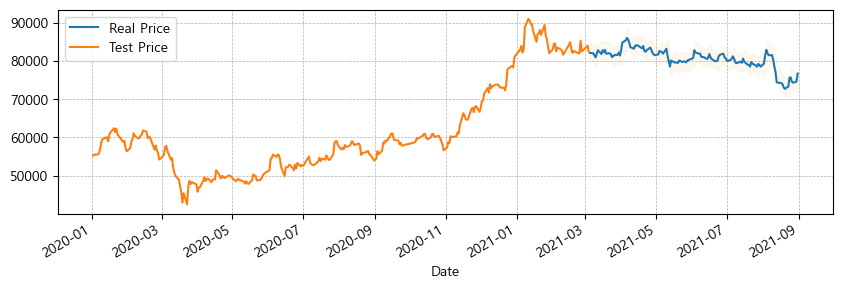

In [497]:
#시각화
plt.figure(figsize=(10,3))
plt.plot(y_test,label='Real Price') #y_test.plot도 가능 (실제주가)
y_train.plot(label='Test Price')
plt.fill_between(lower.index,lower.values,upper.values,color='wheat',alpha=0.2) #00와00사이를 채워라(상한가 하한가 부분을 채움그림)
plt.legend()
plt.grid(True,ls='--',lw=0.5)
plt.show()

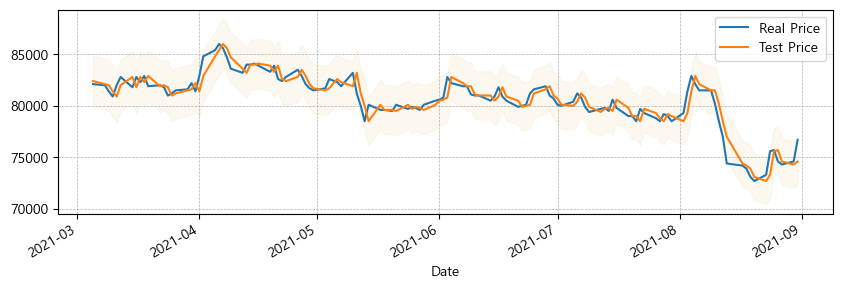

In [498]:
#시각화
plt.figure(figsize=(10,3))
y_test.plot(label='Real Price') #y_test.plot도 가능 (실제주가)
plt.plot(pred,label='Test Price')
plt.fill_between(lower.index,lower.values,upper.values,color='wheat',alpha=0.2) #00와00사이를 채워라(상한가 하한가 부분을 채움그림)
plt.legend()
plt.grid(True,ls='--',lw=0.5)
plt.show()


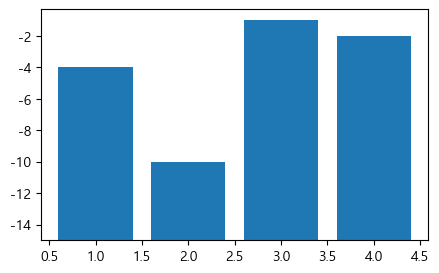

In [499]:
plt.figure(figsize=(5,3))
x=[1,2,3,4]
y=[-4,-10,-1,-2]
miny=min(y)-5
plt.bar(x,[i-miny for i in y],bottom=miny)
plt.show()

In [500]:
#주가 데이터 웹페이지 만들기
  #티커 구하기(==종목코드 구하기)

import FinanceDataReader as fdr
df=fdr.StockListing('KRX')
  # df.head()
names=['삼성전자','롯데지주','NAVER','카카오','LG전자','현대차']
  #isin은 names에 속해있으면 출력을 해줌
filt=df['Name'].isin(names)
df=df[filt][['Code','Name']]
names=list(df['Name'])
codes=list(df['Code'])

# 삼성전자의 start-end까지의 주식 데이터 가져오기(code,start,end는 front에서 받아올 내역)
# code='005930' #삼성전자
# start='2025-01-01'
# end='2025-09-30'
names,codes



(['삼성전자', '현대차', 'NAVER', '카카오', 'LG전자', '롯데지주'],
 ['005930', '005380', '035420', '035720', '066570', '004990'])

In [501]:
# 삼성전자의 start-end까지의 주식 데이터 가져오기(code,start,end는 front에서 받아올 내역)
code=codes[0]
start='2025-01-01'
end='2025-09-30'
df=fdr.DataReader(code,start,end)
y_train=df['Close']

In [502]:
  #모델 생성하는 함수
import pmdarima as pm
import warnings
warnings.filterwarnings('ignore')
model=pm.auto_arima(
    y_train, d=1, start_P=0,max_p=3, start_q=0, max_q=3, seasonal=False, trace=True
)
model.fit(y_train)


  

Performing stepwise search to minimize aic
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=3102.073, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=3100.891, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=3102.734, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=3102.746, Time=0.01 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=3102.417, Time=0.00 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=3104.175, Time=0.04 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0] intercept
Total fit time: 0.106 seconds


,order,"(0, ...)"
,seasonal_order,"(0, ...)"
,start_params,None
,method,'lbfgs'
,maxiter,50
,suppress_warnings,True
,out_of_sample_size,0
,scoring,'mse'
,scoring_args,{}
,trend,None
,with_intercept,True


In [503]:
#예측함수
def one_step():
    pred, conf = model.predict(n_periods=1, return_conf_int=True)
    return pred.tolist()[0], conf[0]


  #예측하는 함수 실행
pred=[]
lower=[]
upper=[]
for y in y_train:
    y_pred, conf=one_step()
    pred.append(y_pred)
    lower.append(conf[0])
    upper.append(conf[1])
    model.update(y)

  #확인 출력
pred[:5],upper[:5],lower[:5]


([84067.58241758242,
  53465.14213202203,
  54418.10981076385,
  55918.10981076385,
  55418.10981076385],
 [86417.0194043793,
  57980.174708960876,
  59400.596736268686,
  60900.596736268686,
  60400.596736268686],
 [81718.14543078555,
  48950.10955508319,
  49435.62288525902,
  50935.62288525902,
  50435.62288525902])

In [504]:
  #결과를 DataFrame으로 만들기(훈련데이터를 y_train Dataframe으로만들기)
df=pd.DataFrame(y_train)
df['예측가']=pred
df['하한가']=lower
df['상한가']=upper
df

,Close,예측가,하한가,상한가
Date,,,,
2025-01-02,53400,84067.582418,81718.145431,86417.019404
2025-01-03,54400,53465.142132,48950.109555,57980.174709
2025-01-06,55900,54418.109811,49435.622885,59400.596736
2025-01-07,55400,55918.109811,50935.622885,60900.596736
2025-01-08,57300,55418.109811,50435.622885,60400.596736
...,...,...,...,...
2025-09-24,85400,84749.317063,80789.092395,88709.541732
2025-09-25,86100,85449.317063,81489.092395,89409.541732
2025-09-26,83300,86153.126803,82199.248873,90107.004734


Text(0.5, 1.0, '삼성전자2025-01-01~2025-09-30 주가예측')

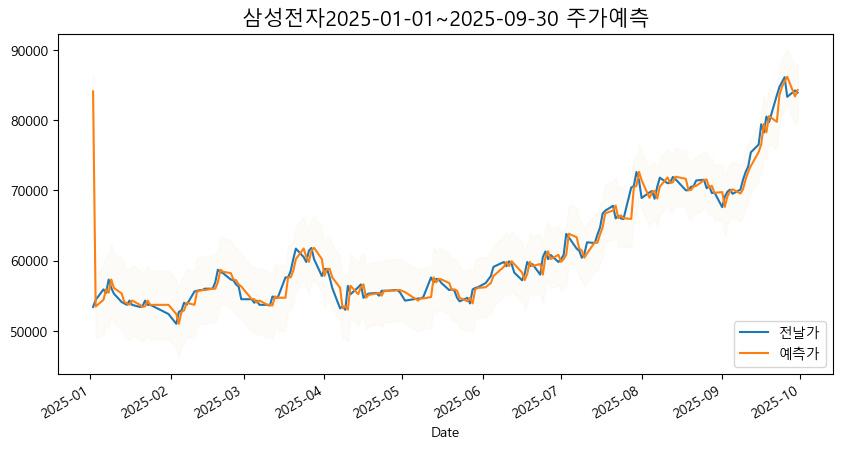

In [505]:
# 그래프 출력하기
import matplotlib.pyplot as plt
plt.rc('font',family='Malgun Gothic')
plt.rc('axes',unicode_minus=False)
plt.figure(figsize=(10,5))
df['Close'].plot(label='전날가')
df['예측가'].plot(label='예측가')
# df['하한가'].plot(label='하한가')
# df['상한가'].plot(label='상한가')
plt.fill_between(df.index,df['하한가'],df['상한가'],color='wheat',alpha=0.1) #해당되는 범위를 색깔로 채워줌
plt.legend()
plt.title(f'삼성전자{start}~{end} 주가예측',size=15)


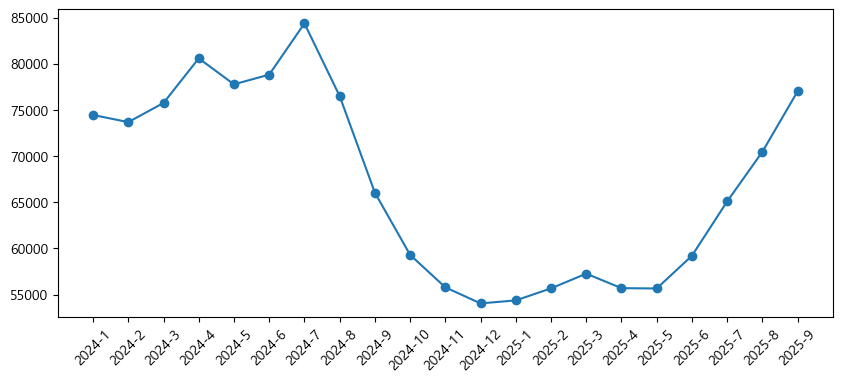

In [506]:
code="005930"
start="2024-01-01"
end="2025-09-30"
df=fdr.DataReader(code,start,end)
df['year']=df.index.year
df['month']=df.index.month
#Close에 대한 평균
group=df.groupby(['year','month'])[['Close','Volume']].mean()
group.reset_index(inplace=True)
group
plt.figure(figsize=(10,4))
plt.plot(group.index,group["Close"],marker='o')
xticks=[x for x in group.index] #range()
plt.xticks(xticks,[f'{group.loc[idx, "year"]}-{group.loc[idx,"month"]}' for idx in xticks],rotation=45)

plt.show()


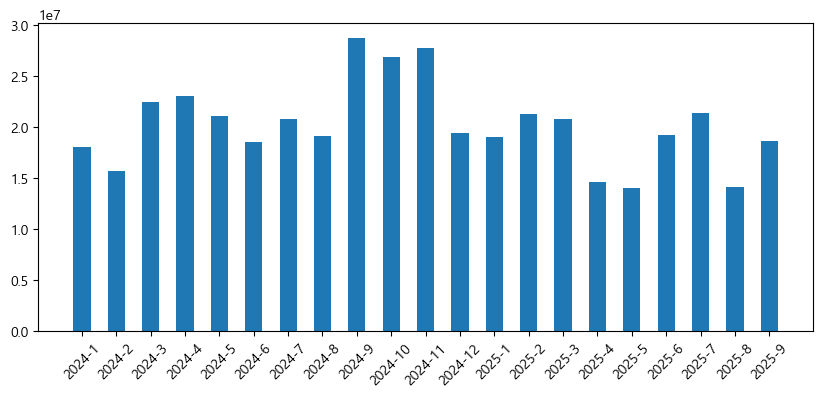

In [507]:
plt.figure(figsize=(10,4))
plt.bar(group.index,group["Volume"], width=0.5)
xticks=[x for x in group.index] #range()
plt.xticks(xticks,[f'{group.loc[idx, "year"]}-{group.loc[idx,"month"]}' for idx in xticks],rotation=45)
plt.show()